Caricamento dei dati

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving tableau_sales_dataset_1500_rows.csv to tableau_sales_dataset_1500_rows.csv


Import delle librerie necessarie

In [ ]:
import pandas as pd

Import dei dati

Cliccando sul segno della tabella, la si trasforma in una tabella interattiva, che può essere filtrata a piacere, come se fosse un foglio di Excel

In [ ]:
df = pd.read_csv("tableau_sales_dataset_1500_rows.csv")
df.head(10) #first 5 rows by default

,Order_Date,Country,City,Category,Segment,Sales,Quantity,Profit
0,2024-11-10,Sweden,Stockholm,Clothing,Consumer,354.24,3,-51.37
1,2024-02-09,Netherlands,Amsterdam,Groceries,Home Office,1457.90,6,-290.96
2,2022-01-22,Spain,Madrid,Electronics,Corporate,63.78,9,-2.54
3,2022-07-09,Netherlands,Utrecht,Furniture,Home Office,226.68,3,2.35
4,2023-10-09,Spain,Madrid,Clothing,Consumer,382.52,7,-73.71
5,2024-02-16,Germany,Munich,Furniture,Corporate,81.13,2,14.31
6,2024-02-15,Sweden,Malmo,Groceries,Consumer,117.06,1,-6.75
7,2023-12-04,Belgium,Antwerp,Furniture,Corporate,1692.46,2,29.33
8,2022-10-23,Spain,Barcelona,Groceries,Consumer,1696.84,2,164.31
9,2024-11-30,Belgium,Antwerp,Electronics,Consumer,627.73,1,-120.15


Descrizione del dataframe

shape: (righe, colonne)

columns: numero di colonne

info(): informazioni sul dataset, numero di dati non nulli e tipo di dato nella colonna

tail(): ultimi dati

describe(): solo per le celle quantitative, fa la statistica

In [ ]:
df.shape
df.columns
df.info()
df.tail(10)
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Order_Date  1500 non-null   object 
 1   Country     1500 non-null   object 
 2   City        1500 non-null   object 
 3   Category    1500 non-null   object 
 4   Segment     1500 non-null   object 
 5   Sales       1500 non-null   float64
 6   Quantity    1500 non-null   int64  
 7   Profit      1500 non-null   float64
dtypes: float64(2), int64(1), object(5)
memory usage: 93.9+ KB


,Sales,Quantity,Profit
count,1500.000000,1500.000000,1500.000000
mean,1023.718687,4.986000,63.262427
std,557.929836,2.608385,192.122176
min,52.410000,1.000000,-380.830000
25%,535.897500,3.000000,-55.277500
50%,1024.265000,5.000000,32.545000
75%,1512.262500,7.000000,176.660000
max,1998.150000,9.000000,689.570000


Trovare i valori nulli

In [ ]:
df.isnull().sum()

,0
Order_Date,0
Country,0
City,0
Category,0
Segment,0
Sales,0
Quantity,0
Profit,0


Record duplicati

In [ ]:
df.duplicated().sum()

np.int64(0)

Valori univoci in una colonna specifica

In [ ]:
df["Category"].unique()
df["City"].value_counts()

,count
City,
Milan,77
Valencia,75
Munich,74
Brussels,74
Stockholm,70
Hamburg,69
Berlin,69
Naples,68
Paris,68


Matplotlib per visualizzare i dati

In [ ]:
import matplotlib.pyplot as plt

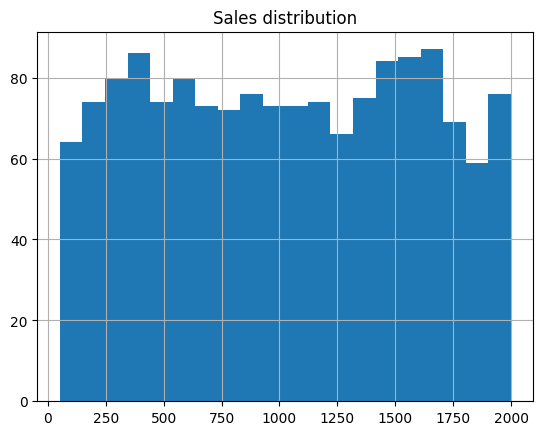

In [ ]:
df["Sales"].hist(bins=20)
plt.title("Sales distribution")
plt.show()

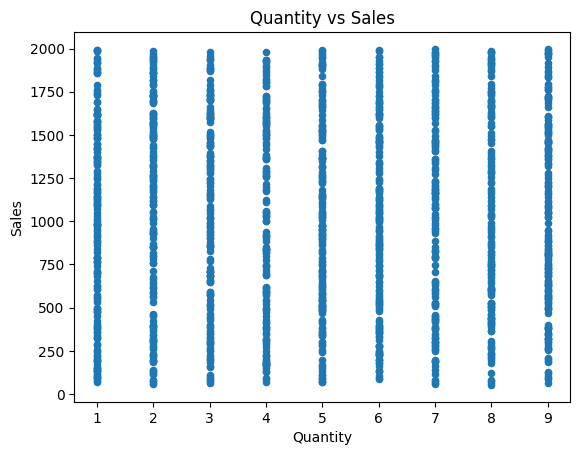

In [ ]:
df.plot.scatter(x="Quantity", y="Sales")
plt.title("Quantity vs Sales")
plt.show()

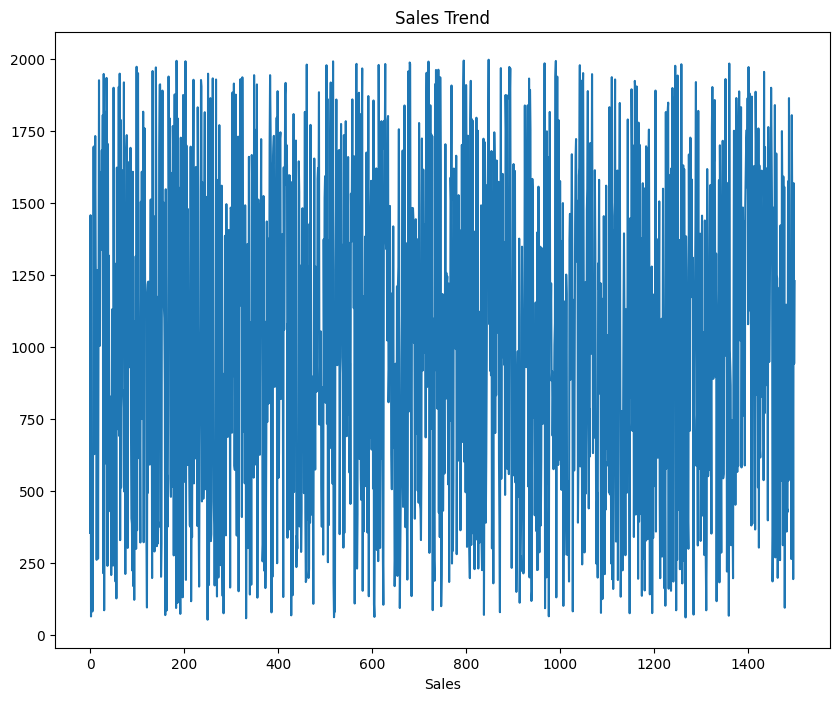

In [ ]:
plt.figure(figsize=(10,8))
plt.plot(df["Sales"])
plt.title("Sales Trend")
plt.xlabel("Index")
plt.xlabel("Sales")
plt.show()

Sklearn per il ML

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

Definire input (x) e output (y) del modello di ML

In [ ]:
x = df[["Quantity"]]
y = df ["Sales"]

Stabilisco train e test set; test data sarà il 20% del totale

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2)

Creo il modello e lo addestro

In [18]:
model = LinearRegression()
model.fit(x_train, y_train)

LinearRegression()

Applico il modello a nuovi dati, su cui non ha ancora lavorato

In [19]:
predictions = model.predict(x_test)

Testo quanto il modello è buono

In [21]:
comparison = pd.DataFrame({"Actual":y_test, "Predicted":predictions})
comparison.head()

,Actual,Predicted
1073,685.12,1014.268425
1476,348.93,1033.076049
103,1164.64,1042.479861
536,1355.15,1042.479861
1274,1668.88,1018.970331


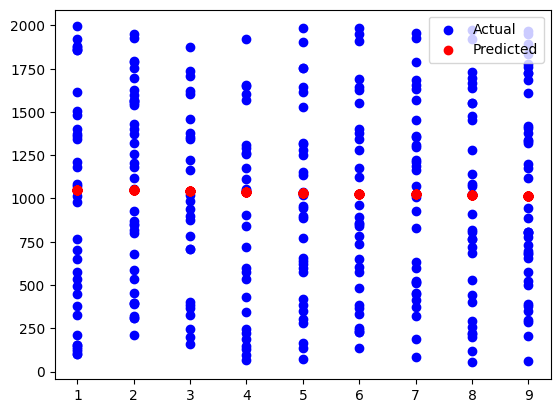

In [22]:
plt.scatter(x_test, y_test, color="blue", label="Actual")
plt.scatter(x_test, predictions, color="red", label="Predicted")
plt.legend()
plt.show()

Regressione con decision trees

In [23]:
from sklearn.tree import DecisionTreeRegressor

In [24]:
tree_model = DecisionTreeRegressor()
tree_model.fit(x_train, y_train)

DecisionTreeRegressor()

In [25]:
tree_predictions = tree_model.predict(x_test)

In [26]:
comparison = pd.DataFrame({"Actual":y_test, "Predicted":tree_predictions})
comparison.head()

,Actual,Predicted
1073,685.12,1005.976500
1476,348.93,1011.539178
103,1164.64,1061.803806
536,1355.15,1061.803806
1274,1668.88,1028.852459


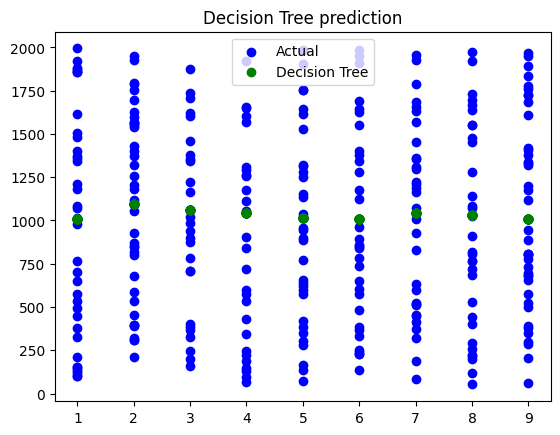

In [28]:
plt.scatter(x_test, y_test, color="blue", label="Actual")
plt.scatter(x_test, tree_predictions, color="green", label="Decision Tree")
plt.legend()
plt.title("Decision Tree prediction")
plt.show()